In [25]:
import hotspot
import scanpy as sc
import numpy as np
import h5py
import os
import pandas as pd
from scipy.sparse import csc_matrix
import anndata as ad


In [2]:
dts_name = "masld_immune"
input_path = f"/mnt/d/Starlng_paper/data/{dts_name}.h5ad"
output_path = f"/mnt/d/Starlng_paper/comparison_with_other_methods/hotspot_results"
if not os.path.exists(output_path):
    os.makedirs(output_path)

In [3]:
adata = sc.read_h5ad(input_path)
adata.X = adata.layers["counts"]
adata.obs["total_counts"] = adata.X.sum(axis=1)
adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes = 5)
sc.pp.filter_genes(adata, min_cells = 5)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["log_normalized"] = adata.layers["counts"]
sc.pp.scale(adata)

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
# sc.pp.pca(adata, mask_var = None)
adata.layers["counts"] = adata.layers["counts"].todense()

/home/andi/.local/lib/python3.12/site-packages/anndata/_core/aligned_mapping.py:219: ImplicitModificationWarning: Layer 'counts' should not be a np.matrix, use np.ndarray instead.
  value = self._validate_value(value, key)


In [5]:
hs = hotspot.Hotspot(
    adata,
    layer_key = "counts",
    model = "danb",
    latent_obsm_key = "pca",
    umi_counts_obs_key = "total_counts"
)



In [6]:
np.random.seed(42)
hs.create_knn_graph(weighted_graph = False, n_neighbors = 30)
hs_results = hs.compute_autocorrelations(jobs = 4)

100%|██████████| 24539/24539 [00:20<00:00, 1202.56it/s]


In [8]:
hs.__dict__

{'adata': AnnData object with n_obs × n_vars = 9239 × 24539
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Patient.ID', 'Disease.status', 'non.NAFLD.disease', 'Lobe', 'manuscript.expt', 'SAF.Score', 'Steatosis', 'Ballooning', 'Inflammation', 'Fibrosis.score..F0.4.', 'Gender', 'Age', 'BMI', 'Ethnic.group', 'Diabetes.type.2', 'hypertension', 'dyslipidaemia', 'cardiovascular.disease', 'obstructive.sleep.apnoea', 'percent.mt.RNA', 'percent.rp.RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'SCT_snn_res.0.3', 'SCT_snn_res.0.5', 'SCT_snn_res.0.7', 'SCT_snn_res.0.9', 'SCT_snn_res.1.1', 'SCT_snn_res.1.3', 'SCT_snn_res.1.5', 'SCT_snn_res.2', 'seurat_clusters', 'cell.annotation.version', 'cell.annotation', 'SCT_snn_orig.0.1', 'SCT_snn_res.0.4', 'SCT_snn_orig.0.4', 'SCT_snn_res.0.8', 'SCT_snn_orig.0.8', 'SCT_snn_res.1.2', 'SCT_snn_orig.1.2', 'SCT_snn_res.1.6', 'SCT_snn_orig.1.6', 'SCT_snn_harmony_t.0.0.1', 'SCT_snn_harmony_t.0.0.4', 'SCT_snn_harmony_t.0.0.8', 'SCT_snn_harmony_t.0.1

In [20]:
hs_genes = hs_results.loc[hs_results.FDR < 1e-95].sort_values('Z', ascending=False)
print(f"Number of genes with FDR < 0.01: {hs_genes.shape[0]}")
hs_genes = hs_genes.index

Number of genes with FDR < 0.01: 3309


In [21]:
lcz = hs.compute_local_correlations(hs_genes, jobs = 10)

modules = hs.create_modules(
    min_gene_threshold = 20,
    fdr_threshold = 1e-95,
    core_only = True
)

Computing pair-wise local correlation on 3309 features...


100%|██████████| 5473086/5473086 [17:29<00:00, 5212.50it/s]


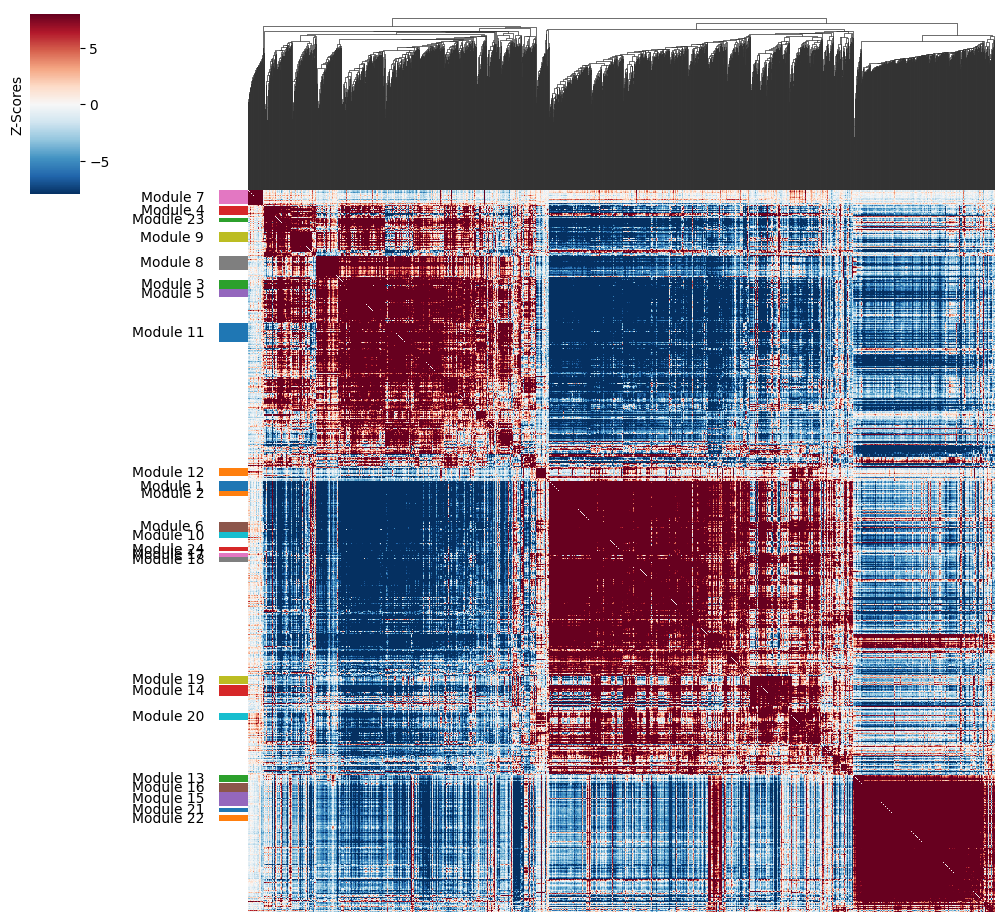

In [22]:
hs.plot_local_correlations()

In [26]:
import pickle
with open(f"{output_path}/hotspot_object.pkl", "wb") as f:
    pickle.dump(hs, f)

In [27]:
output_path

'/mnt/d/Starlng_paper/comparison_with_other_methods/hotspot_results'

In [24]:
hs.__dict__

{'adata': AnnData object with n_obs × n_vars = 9239 × 24539
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Patient.ID', 'Disease.status', 'non.NAFLD.disease', 'Lobe', 'manuscript.expt', 'SAF.Score', 'Steatosis', 'Ballooning', 'Inflammation', 'Fibrosis.score..F0.4.', 'Gender', 'Age', 'BMI', 'Ethnic.group', 'Diabetes.type.2', 'hypertension', 'dyslipidaemia', 'cardiovascular.disease', 'obstructive.sleep.apnoea', 'percent.mt.RNA', 'percent.rp.RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'SCT_snn_res.0.3', 'SCT_snn_res.0.5', 'SCT_snn_res.0.7', 'SCT_snn_res.0.9', 'SCT_snn_res.1.1', 'SCT_snn_res.1.3', 'SCT_snn_res.1.5', 'SCT_snn_res.2', 'seurat_clusters', 'cell.annotation.version', 'cell.annotation', 'SCT_snn_orig.0.1', 'SCT_snn_res.0.4', 'SCT_snn_orig.0.4', 'SCT_snn_res.0.8', 'SCT_snn_orig.0.8', 'SCT_snn_res.1.2', 'SCT_snn_orig.1.2', 'SCT_snn_res.1.6', 'SCT_snn_orig.1.6', 'SCT_snn_harmony_t.0.0.1', 'SCT_snn_harmony_t.0.0.4', 'SCT_snn_harmony_t.0.0.8', 'SCT_snn_harmony_t.0.1

In [ ]:
ad.write_h5ad()